In [1]:
# ===============================================================
#  EXPLORACIÓN INICIAL DE DATOS ECU 911 (Ecuador)
#  Autor: Brandon Minta
#  Descripción:
#  Este notebook permite cargar y explorar archivos CSV mensuales
#  de emergencias del ECU911 para identificar estructura, nulos,
#  duplicados e inconsistencias antes de unificarlos.
# ===============================================================

# ---------------------------------------------------------------
# 1. IMPORTAR LIBRERÍAS
# ---------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración visual
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

# ---------------------------------------------------------------
# 2. CARGAR UNO O VARIOS ARCHIVOS DE PRUEBA
# ---------------------------------------------------------------
# Cambia estos nombres según lo que quieras explorar
archivo_1 = "../data/raw/emergencias_enero_2023.csv"
archivo_2 = "../data/raw/emergencias_febrero_2023.csv"

df1 = pd.read_csv(archivo_1, sep=';', encoding='utf-8', dayfirst=True)
df2 = pd.read_csv(archivo_2, sep=';', encoding='utf-8', dayfirst=True)

# Unirlos para pruebas (no todos aún)
df = pd.concat([df1, df2], ignore_index=True)
print("Total de filas:", len(df))
df.head()


Total de filas: 557048


,Fecha,provincia,Canton,Cod_Parroquia,Parroquia,Servicio,Subtipo
0,01/01/2023,PICHINCHA,QUITO,170150.0,"QUITO DISTRITO METROPOLITANO, CABECERA CANTONA...",Tránsito y Movilidad,Otros
1,01/01/2023,PICHINCHA,QUITO,170150.0,"QUITO DISTRITO METROPOLITANO, CABECERA CANTONA...",Seguridad Ciudadana,Patrullaje policial en el sector solicitado
2,01/01/2023,PICHINCHA,QUITO,170150.0,"QUITO DISTRITO METROPOLITANO, CABECERA CANTONA...",Seguridad Ciudadana,Ficha de datos información
3,01/01/2023,PICHINCHA,QUITO,170156.0,CONOCOTO,Seguridad Ciudadana,Patrullaje policial en el sector solicitado
4,01/01/2023,PICHINCHA,QUITO,170150.0,"QUITO DISTRITO METROPOLITANO, CABECERA CANTONA...",Gestión Sanitaria,Caída


In [2]:
print("-----------------------------REVISAR INFORMACIÓN BÁSICA-----------------------------\n")
df.info()
df.describe(include='all')

print("-----------------------------REVISAR COLUMNAS DISPONIBLES-----------------------------\n")
print("Columnas:", list(df.columns))
print("\nValores únicos por columna:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} únicos")

print("-----------------------------REVISAR NULOS Y DUPLICADOS-----------------------------\n")
print("\nValores nulos:")
print(df.isna().sum())

duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}")

print("-----------------------------Fechas-----------------------------\n")
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce", dayfirst=True)

-----------------------------REVISAR INFORMACIÓN BÁSICA-----------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 557048 entries, 0 to 557047
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Fecha          557048 non-null  object 
 1   provincia      557024 non-null  object 
 2   Canton         557024 non-null  object 
 3   Cod_Parroquia  557024 non-null  float64
 4   Parroquia      557024 non-null  object 
 5   Servicio       557046 non-null  object 
 6   Subtipo        557048 non-null  object 
dtypes: float64(1), object(6)
memory usage: 29.7+ MB
-----------------------------REVISAR COLUMNAS DISPONIBLES-----------------------------

Columnas: ['Fecha', 'provincia', 'Canton', 'Cod_Parroquia', 'Parroquia', 'Servicio', 'Subtipo']

Valores únicos por columna:
Fecha: 59 únicos
provincia: 25 únicos
Canton: 221 únicos
Cod_Parroquia: 1024 únicos
Parroquia: 963 únicos
Servicio: 7 únicos
Subtipo:

### Revision de Provincias

In [3]:
df['provincia'].dropna().unique()

array(['PICHINCHA', 'ORELLANA', 'NAPO', 'LOS RIOS', 'COTOPAXI', 'MANABI',
       'ESMERALDAS', 'AZUAY', 'TUNGURAHUA', 'MORONA SANTIAGO',
       'SUCUMBIOS', 'LOJA', 'PASTAZA', 'IMBABURA', 'BOLIVAR', 'GUAYAS',
       'EL ORO', 'SANTO DOMINGO DE LOS TSACHILAS', 'CAÑAR', 'CHIMBORAZO',
       'CARCHI', 'SANTA ELENA', 'ZAMORA CHINCHIPE', 'ZONA NO DELIMITADA',
       'GALAPAGOS'], dtype=object)

In [4]:
df['provincia'].value_counts().loc['ZONA NO DELIMITADA']

129

### Revision de Fecha

In [5]:
df['Fecha'].dropna().unique()

<DatetimeArray>
['2023-01-01 00:00:00', '2023-01-02 00:00:00', '2023-01-03 00:00:00',
 '2023-01-04 00:00:00', '2023-01-05 00:00:00', '2023-01-06 00:00:00',
 '2023-01-07 00:00:00', '2023-01-08 00:00:00', '2023-01-09 00:00:00',
 '2023-01-10 00:00:00', '2023-01-11 00:00:00', '2023-01-12 00:00:00',
 '2023-01-13 00:00:00', '2023-01-14 00:00:00', '2023-01-15 00:00:00',
 '2023-01-16 00:00:00', '2023-01-17 00:00:00', '2023-01-18 00:00:00',
 '2023-01-19 00:00:00', '2023-01-20 00:00:00', '2023-01-21 00:00:00',
 '2023-01-22 00:00:00', '2023-01-23 00:00:00', '2023-01-24 00:00:00',
 '2023-01-25 00:00:00', '2023-01-26 00:00:00', '2023-01-27 00:00:00',
 '2023-01-28 00:00:00', '2023-01-29 00:00:00', '2023-01-30 00:00:00',
 '2023-01-31 00:00:00', '2023-02-01 00:00:00', '2023-02-02 00:00:00',
 '2023-02-03 00:00:00', '2023-02-04 00:00:00', '2023-02-05 00:00:00',
 '2023-02-06 00:00:00', '2023-02-07 00:00:00', '2023-02-08 00:00:00',
 '2023-02-09 00:00:00', '2023-02-10 00:00:00', '2023-02-11 00:00:00',
 '20

### AGRUPACIONES 

In [10]:
agrupado = (
    df.groupby(['Fecha', 'provincia', 'Canton', 'Cod_Parroquia', 'Parroquia', 'Servicio', 'Subtipo'])
      .size()
      .reset_index(name='cantidad_eventos')
)


In [11]:
agrupado

,Fecha,provincia,Canton,Cod_Parroquia,Parroquia,Servicio,Subtipo,cantidad_eventos
0,2023-01-01,AZUAY,CAMILO PONCE ENRIQUEZ,11550.0,"CAMILO PONCE ENRÍQUEZ, CABECERA CANTONAL",Gestión Sanitaria,Problemas digestivos,1
1,2023-01-01,AZUAY,CAMILO PONCE ENRIQUEZ,11550.0,"CAMILO PONCE ENRÍQUEZ, CABECERA CANTONAL",Seguridad Ciudadana,Escándalo en espacio privado,2
2,2023-01-01,AZUAY,CAMILO PONCE ENRIQUEZ,11550.0,"CAMILO PONCE ENRÍQUEZ, CABECERA CANTONAL",Seguridad Ciudadana,Escándalo en espacio público,2
3,2023-01-01,AZUAY,CAMILO PONCE ENRIQUEZ,11550.0,"CAMILO PONCE ENRÍQUEZ, CABECERA CANTONAL",Seguridad Ciudadana,Libadores,3
4,2023-01-01,AZUAY,CAMILO PONCE ENRIQUEZ,11550.0,"CAMILO PONCE ENRÍQUEZ, CABECERA CANTONAL",Seguridad Ciudadana,Patrullaje policial en el sector solicitado,9
...,...,...,...,...,...,...,...,...
132517,2023-02-28,ZAMORA CHINCHIPE,ZAMORA,190155.0,SABANILLA,Tránsito y Movilidad,Seguridad Ciudadana,1
132518,2023-02-28,ZAMORA CHINCHIPE,ZAMORA,190156.0,TIMBARA,Seguridad Ciudadana,Seguridad Ciudadana,1
132519,2023-02-28,ZAMORA CHINCHIPE,ZAMORA,190158.0,SAN CARLOS DE LAS MINAS,Gestión Sanitaria,Gestión Sanitaria,1
132520,2023-02-28,ZONA NO DELIMITADA,EL PIEDRERO,900451.0,EL PIEDRERO,Seguridad Ciudadana,Seguridad Ciudadana,1


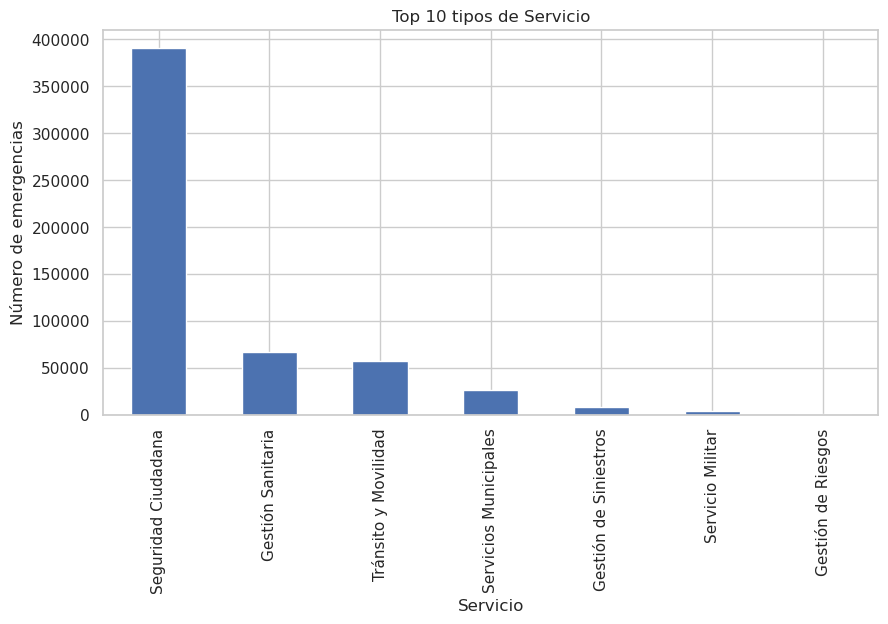

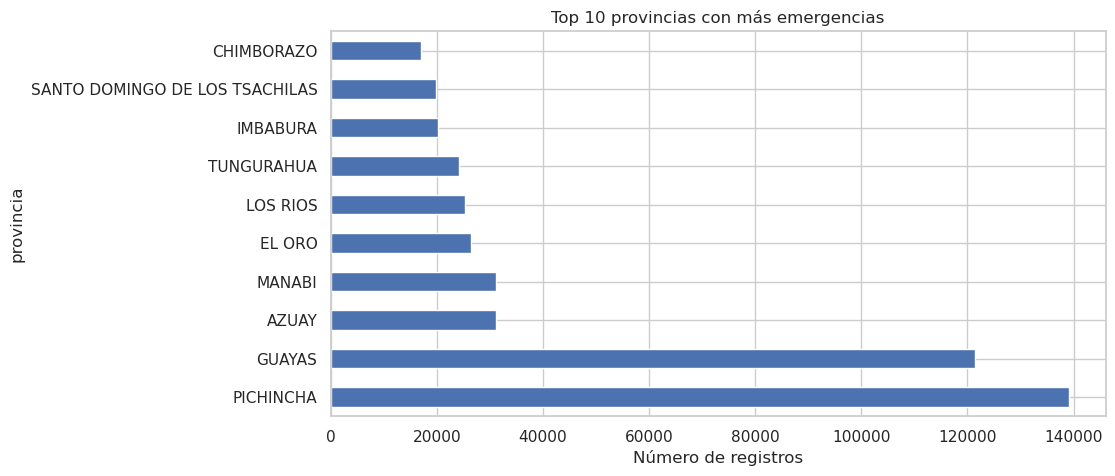


Valores únicos de 'Fecha' (muestra):
<DatetimeArray>
['2023-01-01 00:00:00', '2023-01-02 00:00:00', '2023-01-03 00:00:00',
 '2023-01-04 00:00:00', '2023-01-05 00:00:00', '2023-01-06 00:00:00',
 '2023-01-07 00:00:00', '2023-01-08 00:00:00', '2023-01-09 00:00:00',
 '2023-01-10 00:00:00']
Length: 10, dtype: datetime64[ns]

Valores únicos de 'provincia' (muestra):
['PICHINCHA' 'ORELLANA' 'NAPO' 'LOS RIOS' 'COTOPAXI' 'MANABI' 'ESMERALDAS'
 'AZUAY' 'TUNGURAHUA' 'MORONA SANTIAGO']

Valores únicos de 'Canton' (muestra):
['QUITO' 'ORELLANA' 'ARCHIDONA' 'TENA' 'SAN MIGUEL DE LOS BANCOS'
 'RUMIÑAHUI' 'PEDRO VICENTE MALDONADO' 'MEJIA' 'CAYAMBE'
 'LA JOYA DE LOS SACHAS']

Valores únicos de 'Cod_Parroquia' (muestra):
[170150. 170156. 170155. 170185. 170177. 220150. 170184. 170157. 150352.
 170179.]

Valores únicos de 'Parroquia' (muestra):
['QUITO DISTRITO METROPOLITANO, CABECERA CANTONAL, *' 'CONOCOTO'
 'CALDERÓN (CARAPUNGO)' 'YARUQUÍ' 'POMASQUI'
 'PUERTO FRANCISCO DE ORELLANA (EL COCA),CABECERA C

In [12]:
# Distribución por tipo de servicio
plt.figure()
df["Servicio"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 tipos de Servicio")
plt.ylabel("Número de emergencias")
plt.show()

# Distribución por provincia
plt.figure()
df["provincia"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 provincias con más emergencias")
plt.xlabel("Número de registros")
plt.show()

# ---------------------------------------------------------------
# 7. DETECTAR POSIBLES INCONSISTENCIAS DE TEXTO
# ---------------------------------------------------------------
for col in ['Fecha', 'provincia', 'Canton', 'Cod_Parroquia', 'Parroquia', 'Servicio', 'Subtipo']:
    print(f"\nValores únicos de '{col}' (muestra):")
    print(df[col].dropna().unique()[:10])

# Ejemplo de estandarización: 
# df["Servicio"] = df["Servicio"].str.title().str.strip()

# ---------------------------------------------------------------
# 8. RECOMENDACIONES DE LIMPIEZA (manual)
# ---------------------------------------------------------------
# - Unificar mayúsculas/minúsculas en columnas de texto
# - Eliminar filas sin Fecha o Provincia
# - Estandarizar nombres de cantones/parroquias con tildes
# - Analizar subtipos más frecuentes para agrupar o reducir categorías
# - Crear variables derivadas (Año, Mes, etc.)

